In [5]:
import sys
sys.path.append("../../src/")
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time
#Imports
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter

In [6]:
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n_correlations(n,l, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [80]:
from itertools import combinations

def even_combinations(indices):
    x = []
    for r in range(2, len(indices) + 1, 2):
        x.extend(combinations(indices, r))
    return list(x)

list1 = [1, 2, 3]
list2 = [11, 12, 13]
combined = list1 + list2

terms = even_combinations(combined)

# Keep only terms that have at least one element from each list
terms = [t for t in terms if any(x in list1 for x in t) and any(x in list2 for x in t)]
terms

[(1, 11),
 (1, 12),
 (1, 13),
 (2, 11),
 (2, 12),
 (2, 13),
 (3, 11),
 (3, 12),
 (3, 13),
 (1, 2, 3, 11),
 (1, 2, 3, 12),
 (1, 2, 3, 13),
 (1, 2, 11, 12),
 (1, 2, 11, 13),
 (1, 2, 12, 13),
 (1, 3, 11, 12),
 (1, 3, 11, 13),
 (1, 3, 12, 13),
 (1, 11, 12, 13),
 (2, 3, 11, 12),
 (2, 3, 11, 13),
 (2, 3, 12, 13),
 (2, 11, 12, 13),
 (3, 11, 12, 13),
 (1, 2, 3, 11, 12, 13)]

In [151]:
from itertools import combinations

def odd_from_both(list1, list2):
    combined = list1 + list2
    result = []
    for r in range(2, len(combined) + 1):  # all lengths ≥ 2
        for combo in combinations(combined, r):
            count1 = sum(x in list1 for x in combo)
            count2 = sum(x in list2 for x in combo)
            if count1 % 2 == 1 and count2 % 2 == 1:
                result.append(combo)
    return result

list1 = [1, 2,3,4]
list2 = [11, 12,13,14]

terms = odd_from_both(list1, list2)

print(terms)

[(1, 11), (1, 12), (1, 13), (1, 14), (2, 11), (2, 12), (2, 13), (2, 14), (3, 11), (3, 12), (3, 13), (3, 14), (4, 11), (4, 12), (4, 13), (4, 14), (1, 2, 3, 11), (1, 2, 3, 12), (1, 2, 3, 13), (1, 2, 3, 14), (1, 2, 4, 11), (1, 2, 4, 12), (1, 2, 4, 13), (1, 2, 4, 14), (1, 3, 4, 11), (1, 3, 4, 12), (1, 3, 4, 13), (1, 3, 4, 14), (1, 11, 12, 13), (1, 11, 12, 14), (1, 11, 13, 14), (1, 12, 13, 14), (2, 3, 4, 11), (2, 3, 4, 12), (2, 3, 4, 13), (2, 3, 4, 14), (2, 11, 12, 13), (2, 11, 12, 14), (2, 11, 13, 14), (2, 12, 13, 14), (3, 11, 12, 13), (3, 11, 12, 14), (3, 11, 13, 14), (3, 12, 13, 14), (4, 11, 12, 13), (4, 11, 12, 14), (4, 11, 13, 14), (4, 12, 13, 14), (1, 2, 3, 11, 12, 13), (1, 2, 3, 11, 12, 14), (1, 2, 3, 11, 13, 14), (1, 2, 3, 12, 13, 14), (1, 2, 4, 11, 12, 13), (1, 2, 4, 11, 12, 14), (1, 2, 4, 11, 13, 14), (1, 2, 4, 12, 13, 14), (1, 3, 4, 11, 12, 13), (1, 3, 4, 11, 12, 14), (1, 3, 4, 11, 13, 14), (1, 3, 4, 12, 13, 14), (2, 3, 4, 11, 12, 13), (2, 3, 4, 11, 12, 14), (2, 3, 4, 11, 13, 14)

In [117]:
data= [np.array(t)-t[0] for t in terms]

In [124]:
# Convert all entries to tuples for hashing
data_tuples = [tuple(x) if not isinstance(x, tuple) else x for x in data]

# Count occurrences
counts = Counter(data_tuples)

# Separate into unique list and degeneracy list
unique_terms = list(counts.keys())
degeneracy = list(counts.values())

len(unique_terms)/4/4/4

3.0

In [214]:
import equilibrium_critical_correlations as ec
from equilibrium_critical_correlations import sigma_general
eps= []
x= sigma_general([0,10000])
eps.append(1)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [215]:
print("LOLol")
eps.append(sigma_general([0,1,2,10000])/x)


LOLol


In [216]:
print(" h")
eps.append(sigma_general([0,1,2,3,4,10000])/x)


 h


In [217]:
print(" h")
eps.append(sigma_general([0,1,2,3,4,5,6,10000])/x)
values = [
    1.0,
    3.99426004,
    14.02246034,
    47.49414988,
    158.30672427,
    522.97683215,
    1717.96036362,
    5621.59192113,
    18343.41250938
]


 h


In [221]:
eps.append(sigma_general([0,1,2,3,4,5,6,7,8,10000])/x)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [226]:
from math import comb as nck
epsilons = {1:eps[0], 3:eps[1],5:eps[2],7:eps[3],9:eps[4]}
dat= []
for n in range(1,9+1):
    summ= 0
    for ni in range(1,n+1):
        if ni%2==1:
            #print(n,ni)
            summ+=(nck(n,ni)*epsilons[ni])
    print(f"n={n}")
    dat.append(summ**2/4**(n-1))

n=1
n=2
n=3
n=4
n=5
n=6
n=7
n=8
n=9


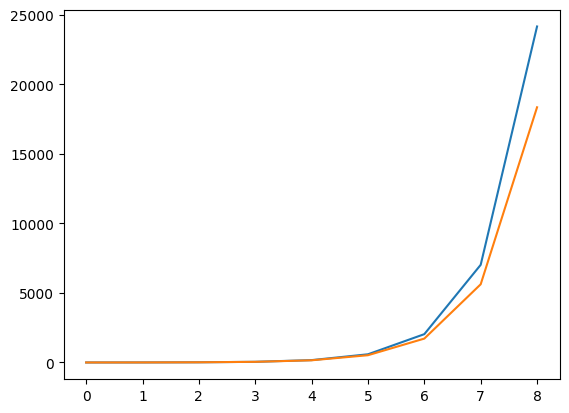

In [232]:
plot([dat[i]*4**i for i in range(0,9)])
plot(values)

In [209]:
values = np.array([
    1.0,
    3.99426004,
    14.02246034,
    47.49414988,
    158.30672427,
    522.97683215,
    1717.96036362,
    5621.59192113,
    18343.41250938
])

normed= [values[i]/4**(i) for i in range(len(values))]

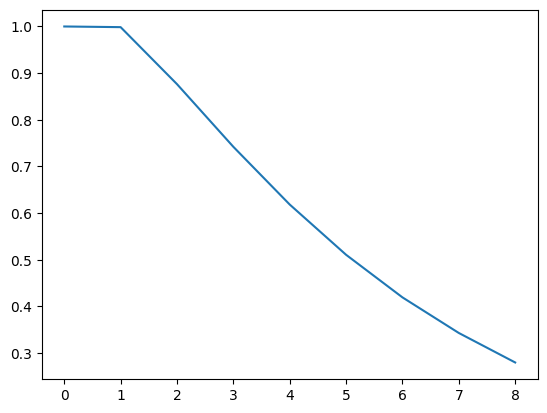

0.0034332030793510497 3.7499866417124608 3.7499866417124608
